# Imports set up rendering

In [1]:

import sys
from pathlib import Path

# Add project root to Python path FIRST to ensure our modules take priority
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print(f"Added {project_root} to Python path")
elif sys.path.index(str(project_root)) != 0:
    # Move to front if it exists but isn't first
    sys.path.remove(str(project_root))
    sys.path.insert(0, str(project_root))
    print(f"Moved {project_root} to front of Python path")

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ['MUJOCO_GL'] = 'egl'
os.environ['PYOPENGL_PLATFORM'] = 'egl'
os.environ["XLA_FLAGS"] = "--xla_gpu_triton_gemm_any=True"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Use GPU 0

# JAX setup
import jax
jax.config.update("jax_compilation_cache_dir", "/tmp/jax_cache")
jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
# Note: jax_persistent_cache_enable_xla_caches may not be available in all JAX versions
try:
    jax.config.update("jax_persistent_cache_enable_xla_caches", "xla_gpu_per_fusion_autotune_cache_dir")
except AttributeError:
    pass  # Skip if not available in this JAX version
jax.config.update("jax_default_matmul_precision", "high")

# Matplotlib setups
import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 10,
    'axes.linewidth': 2,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.major.width': 2,
    'ytick.major.width': 2,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'pdf.fonttype': 42,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
    'pdf.use14corefonts': True,
    'svg.fonttype': 'none',
    'font.family': 'sans-serif',
    'font.serif': 'Arial',
})

Added /home/eabe/Research/MyRepos/3d_tracking_dataset to Python path


In [2]:
%load_ext autoreload
%autoreload 2

# Imports
import numpy as np
import jax.numpy as jnp
import mujoco
import matplotlib.pyplot as plt
import mediapy as media

from omegaconf import DictConfig, OmegaConf
from natsort import natsorted
from pathlib import Path
from tqdm.auto import tqdm

import utils.io_dict_to_hdf5 as ioh5
from utils.add_aligned_keypoint_sites import set_aligned_site_colors
from utils.stac_data_utils import print_bout_dict_structure
from utils.path_utils import (register_custom_resolvers, 
                              create_fresh_config_with_paths, 
                              convert_dict_to_path, 
                              convert_dict_to_string, 
                              load_config_and_override_paths)
register_custom_resolvers()
print("✓ Imports successful")

✓ Imports successful


## 1. Configuration

In [3]:
dataset = 'courtship' 
# base_dir = Path('/data2/users/eabe/datasets/Johnson_lab/free_walking')
base_dir = Path(f'/data2/users/eabe/datasets/Johnson_lab/{dataset}')
version_paths = sorted(list(base_dir.rglob('Predictions_3D*')))
# version_paths = sorted(list(base_dir.rglob('Data_analysis*')))
for n, version_temp in enumerate(version_paths):
    print(n,version_temp)
idx = 0
pre_version = version_paths[idx].name
print(f"Using version: {pre_version}")

0 /data2/users/eabe/datasets/Johnson_lab/courtship/Predictions_3D_20260123-093310
Using version: Predictions_3D_20260123-093310


In [4]:
version = 'Data_analysis'
# base_dir = Path(f'/gscratch/portia/eabe/fly_neuromech/{version}')
base_dir = Path(f'/data2/users/eabe/datasets/Johnson_lab/{dataset}/{version}')
run_cfg_list = natsorted(list(Path(base_dir).rglob('combined_config.yaml')))
for n, run_cfg in enumerate(run_cfg_list):
    temp = OmegaConf.load(run_cfg)
    print(f'{n}:', temp.version, run_cfg)

# ###### Load and update config with specified paths template ###### 
cfg_num = 1

# NEW APPROACH: Load config and replace paths using workstation.yaml template
cfg = load_config_and_override_paths(
    config_path=run_cfg_list[cfg_num],
    new_paths_template="default",    # Use workstation.yaml for local paths
    config_dir=Path.cwd().parent / "configs",
    verbose=False
)

print(f'✅ Loaded experiment: {cfg_num}, {cfg.version}: {run_cfg_list[cfg_num]}')

# Convert string paths to Path objects and create directories
cfg.paths = convert_dict_to_path(cfg.paths)
print("✅ Successfully converted all paths to Path objects and created directories")

fig_dir = cfg.paths.fig_dir
media.set_show_save_dir(fig_dir)

# If combined data not already saved, run the combine_data script to create it
# cfg = create_fresh_config_with_paths(dataset="free_walking", paths_template="workstation", version=version, run_id="analysis", other_overrides=['anatomy=v1'])
# cfg.paths = convert_dict_to_path(cfg.paths)

0: Data_analysis /data2/users/eabe/datasets/Johnson_lab/courtship/Data_analysis/analysis/logs/combined_config.yaml
1: Data_analysis /data2/users/eabe/datasets/Johnson_lab/courtship/Data_analysis/analysis/v1/logs/combined_config.yaml
✅ Loaded experiment: 1, Data_analysis: /data2/users/eabe/datasets/Johnson_lab/courtship/Data_analysis/analysis/v1/logs/combined_config.yaml
✅ Successfully converted all paths to Path objects and created directories


In [30]:

# Preprocessed data file
use_interp = False
preprocessed_path = cfg.paths.base_dir.parent / f'{pre_version}/preprocessing/{cfg.preprocessing.bout_name}.h5'
stac_base = cfg.paths.save_dir / cfg.anatomy.name / cfg.dataset.get('concat', {}).get('output_file', 'ik_output_combined')
if stac_base.exists():
    if use_interp:
        stac_path = stac_base.parent / f"{stac_base.stem}_interpolated.h5"
    else:
        stac_path = stac_base
else:
    stac_path = cfg.paths.data_dir / f"postprocessing/{cfg.postprocessing.output_file}"
# Model paths

skeleton_path = project_root / 'data' / 'fly50.json'
flybody_path = Path(cfg.anatomy.mjcf_path)
# flybody_path = cfg.paths.body_model_dir /'fruitfly_v2.1/fruitfly_v2.1_muscles.xml' # Path(cfg.anatomy.mjcf_path) #
# flybody_path = cfg.paths.body_model_dir /'fruitfly_v1/fruitfly_v1_free.xml' # Path(cfg.anatomy.mjcf_path) #
floor_path = cfg.paths.body_model_dir / 'fruitfly_v2.1/floor.xml' # Path(cfg.anatomy.arena_path) #
print(f"Preprocessed data: {preprocessed_path}")
print(f"stac_path: {stac_path}")
print(f"Model: {flybody_path}")
print(f"Data exists: {preprocessed_path.exists()}")
print(f"STAC data exists: {stac_path.exists()}")
print(f"Model exists: {flybody_path.exists()}")


Preprocessed data: /data2/users/eabe/datasets/Johnson_lab/courtship/Predictions_3D_20260123-093310/preprocessing/preprocessed_bout_v1_courtship.h5
stac_path: /data2/users/eabe/datasets/Johnson_lab/courtship/Data_analysis/analysis/v1/ik_output_combined_v1_courtship.h5
Model: /home/eabe/Research/MyRepos/fruitfly_body_models/fruitfly_v1/fruitfly_v1_free.xml
Data exists: True
STAC data exists: True
Model exists: True


### Example loading

In [31]:
# ── Load STAC output ──────────────────────────────────────────────────────────
# Works for both individual run files and combined batch files.
#
# Individual run (flat format):
#   .../Predictions_3D_XXXXX/stac/Fruitfly_ik_v1_free_walking.h5
# Combined batch (nested format):
#   .../Data_analysis/analysis/ik_output_combined_v1_free_walking.h5

# stac_file_path = '/data2/users/eabe/datasets/Johnson_lab/free_walking/Predictions_3D_20260202-171900/stac/Fruitfly_ik_v1_free_walking.h5'
stac_file_path = stac_path  # path derived from cfg above


stac_data = ioh5.load(stac_file_path, enable_jax=True)
print(f"Loaded: {stac_file_path}")
print(f"Top-level keys: {list(stac_data.keys())[:12]}")


Loaded: /data2/users/eabe/datasets/Johnson_lab/courtship/Data_analysis/analysis/v1/ik_output_combined_v1_courtship.h5
Top-level keys: ['bout_000', 'bout_001', 'bout_002', 'bout_003', 'bout_004', 'bout_005', 'bout_006', 'bout_007', 'info']


In [32]:
def make_videos(
    mj_model,
    mj_data,
    qposes_rollout,
    scene_option,
    camera="track1",
    height=512,
    width=512,
    kp_data=None,
    mocap_indices=None,
    kp_anchor_idx=None,
    model_anchor_site_id=None,
):
    """
    Make a video of the rollout and reference superimposed.
    
    Args:
        kp_data: Optional (T, N_kp, 3) keypoint positions to overlay as mocap bodies.
        mocap_indices: Optional dict mapping keypoint index to mocap ID (from get_aligned_mocap_indices).
        kp_anchor_idx: Index of anchor keypoint (e.g. Scutellum) in kp_data for alignment.
        model_anchor_site_id: MuJoCo site ID of the corresponding anchor site on the body model.
    """
    frames = []
    with mujoco.Renderer(mj_model, height=height, width=width) as renderer:
        for t in tqdm(range(len(qposes_rollout))):
            mj_data.qpos = qposes_rollout[t]
            mujoco.mj_forward(mj_model, mj_data)
            
            # Update mocap body positions for keypoint overlay
            if kp_data is not None and mocap_indices is not None:
                # Compute offset to align kp anchor to model anchor
                offset = np.zeros(3)
                if kp_anchor_idx is not None and model_anchor_site_id is not None:
                    model_anchor_pos = mj_data.site_xpos[model_anchor_site_id]
                    kp_anchor_pos = kp_data[t, kp_anchor_idx, :]
                    offset = model_anchor_pos - kp_anchor_pos
                
                for kp_idx, mocap_id in mocap_indices.items():
                    mj_data.mocap_pos[mocap_id] = kp_data[t, kp_idx, :] + offset
                    mj_data.mocap_quat[mocap_id] = [1, 0, 0, 0]
            
            renderer.update_scene(
                mj_data, camera=f"{camera}", scene_option=scene_option
            )
            renderer.scene.flags[mujoco.mjtRndFlag.mjRND_SHADOW] = False
            pixels = renderer.render()
            frames.append(pixels)
    return frames

In [34]:
from utils.add_aligned_keypoint_sites import add_aligned_mocap_bodies, get_aligned_mocap_indices

clip_lengths = jnp.asarray(stac_data['info']['clip_lengths'])
bout = 1 # np.argmax(clip_lengths)
spec = mujoco.MjSpec().from_file(flybody_path.as_posix())
floor_spec = mujoco.MjSpec().from_file(floor_path.as_posix())
spawn_frame = floor_spec.worldbody.add_frame(
                pos=[0,0,0],
                quat=[1,0,0,0],
            )
spawn_body = spawn_frame.attach_body(spec.body("thorax"), "", suffix='_fly')
if not use_interp:
    end_eff_idxs = jnp.asarray([n for n, name in enumerate(stac_data['info']['names_xpos']) if 'claw' in name])
    floor_z_all = []
    for bout_temp in range(len(clip_lengths)):
        end_z = stac_data[f'bout_{bout_temp:03d}']['xpos'][:, end_eff_idxs, 2]
        floor_z = np.mean(np.quantile(end_z, [0.05], axis=0))
        floor_z_all.append(floor_z)
    floor_z_all = np.array(floor_z_all)
    floor_spec.geom('floor').pos[2] = np.mean(floor_z_all)

# Add mocap bodies for keypoint overlay
kp_names = stac_data['info'].get('kp_names', stac_data[f'bout_{bout:03d}'].get('kp_names', None))
if kp_names is not None:
    floor_spec = add_aligned_mocap_bodies(floor_spec, kp_names, color_coded=True, prefix='aligned_')

mj_model = floor_spec.compile()
mj_data = mujoco.MjData(mj_model)

# Get mocap indices for keypoint visualization
mocap_indices = None
bout_kp_data = None
kp_anchor_idx = None
model_anchor_site_id = None

if kp_names is not None:
    mocap_indices = get_aligned_mocap_indices(mj_model, kp_names, prefix='aligned_')
    bout_kp_data = stac_data[f'bout_{bout:03d}'].get('kp_data', None)
    if bout_kp_data is not None:
        bout_kp_data = np.asarray(bout_kp_data)
        # Reshape from (T, n_kp*3) to (T, n_kp, 3) if stored flat
        if bout_kp_data.ndim == 2 and bout_kp_data.shape[1] == len(kp_names) * 3:
            bout_kp_data = bout_kp_data.reshape(bout_kp_data.shape[0], len(kp_names), 3)
        print(f"Keypoint overlay enabled: {len(kp_names)} keypoints, kp_data shape: {bout_kp_data.shape}")

        # Find Scutellum anchor for alignment
        if 'Scutellum' in kp_names:
            kp_anchor_idx = kp_names.index('Scutellum')
            try:
                model_anchor_site_id = mujoco.mj_name2id(
                    mj_model, mujoco.mjtObj.mjOBJ_SITE, 'tracking[Scutellum]_fly')
                print(f"Scutellum alignment: kp index={kp_anchor_idx}, site id={model_anchor_site_id}")
            except:
                print("Warning: tracking[Scutellum]_fly site not found in model, no alignment")
                model_anchor_site_id = None
    else:
        print("No kp_data found in bout - keypoint overlay disabled")
        mocap_indices = None

t = 0
frames=[]
# qpos_traj =  jnp.concatenate([stac_data[f'bout_{bout:03d}']['qpos'].copy() for bout in [40, 109, 113]],axis=0)
qpos_traj =  stac_data[f'bout_{bout:03d}']['qpos'].copy()

# Trim kp_data to match qpos length
if bout_kp_data is not None:
    bout_kp_data = bout_kp_data[:len(qpos_traj)]

# Set up rendering
height, width = 448, 1936//3
camera = mj_model.camera(0).name
scene_option = mujoco.MjvOption()
scene_option.geomgroup[:] = [1, 1, 1, 0, 0, 0]
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 0]
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True

# Render from multiple camera angles
all_frames = []
for cam in np.asarray([1,2]):
    camera = mj_model.camera(cam).name
    frames = make_videos(mj_model, mujoco.MjData(mj_model), qpos_traj, scene_option,
                         camera=camera, height=height, width=width,
                         kp_data=bout_kp_data, mocap_indices=mocap_indices,
                         kp_anchor_idx=kp_anchor_idx, model_anchor_site_id=model_anchor_site_id)
    all_frames.append(frames)
all_frames = np.concatenate(all_frames, axis=2)
media.show_video(all_frames, fps=60, title=f'clip_concat')

✓ Added 50 mocap bodies with colored sites
Keypoint overlay enabled: 50 keypoints, kp_data shape: (921, 50, 3)
Scutellum alignment: kp index=0, site id=2


  0%|          | 0/921 [00:00<?, ?it/s]

  0%|          | 0/921 [00:00<?, ?it/s]

clip_concat This browser does not support the video tag.


In [9]:
stac_data['info']['kp_names']

['Scutellum',
 'WingL_base',
 'WingR_base',
 'Antenna_Base',
 'EyeL',
 'EyeR',
 'WingL_V12',
 'WingL_V13',
 'WingR_V12',
 'WingR_V13',
 'Abd_A4',
 'Abd_tip',
 'T1L_ThxCx',
 'T1L_Tro',
 'T1L_FeTi',
 'T1L_TiTa',
 'T1L_TaT1',
 'T1L_TaT3',
 'T1L_TaTip',
 'T1R_ThxCx',
 'T1R_Tro',
 'T1R_FeTi',
 'T1R_TiTa',
 'T1R_TaT1',
 'T1R_TaT3',
 'T1R_TaTip',
 'T2L_Tro',
 'T2L_FeTi',
 'T2L_TiTa',
 'T2L_TaT1',
 'T2L_TaT3',
 'T2L_TaTip',
 'T2R_Tro',
 'T2R_FeTi',
 'T2R_TiTa',
 'T2R_TaT1',
 'T2R_TaT3',
 'T2R_TaTip',
 'T3L_Tro',
 'T3L_FeTi',
 'T3L_TiTa',
 'T3L_TaT1',
 'T3L_TaT3',
 'T3L_TaTip',
 'T3R_Tro',
 'T3R_FeTi',
 'T3R_TiTa',
 'T3R_TaT1',
 'T3R_TaT3',
 'T3R_TaTip']

In [36]:
kp_data = stac_data['bout_001']['kp_data'].reshape(stac_data['bout_001']['kp_data'].shape[0], -1, 3)

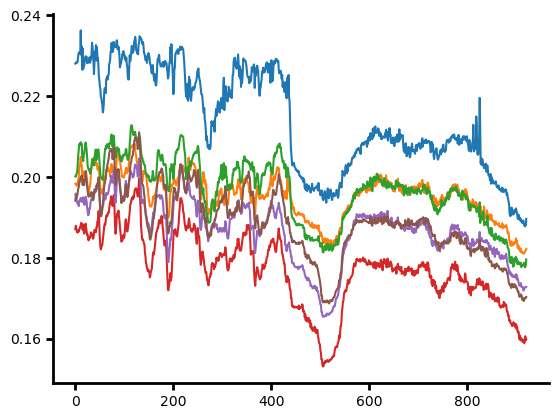

In [37]:
plt.plot(kp_data[:, :6,2])

## Example plotting Egocentric KP

In [ ]:
stac_data.keys()

In [ ]:
wing_V12_idx = np.asarray([idx for idx,name in enumerate(stac_data['egocentric_site_names']) if 'V12' in name], dtype=np.int32)
wing_V13_idx = np.asarray([idx for idx,name in enumerate(stac_data['egocentric_site_names']) if 'V13' in name], dtype=np.int32)
wing_V13_xpos = stac_data['egocentric_site_pos'][:,wing_V13_idx,:]
wing_V12_xpos = stac_data['egocentric_site_pos'][:,wing_V12_idx,:]

In [ ]:
fps = 800
kp_data = stac_data['kp_data'].reshape(stac_data['kp_data'].shape[0], -1, 3)
times = jnp.arange(kp_data.shape[0]) / fps
fig, axs = plt.subplots(2, 3, figsize=(12, 6))
# axs = axs.flatten()
coords = ['x', 'y', 'z']
for n, ax in enumerate(axs[0]):
    coord = coords[n]
    for side_idx, side in enumerate(['L', 'R']):
        ax.plot(times,wing_V13_xpos[:,side_idx,n], label=f'Wing{side}')
        ax.set_title(f'Wing_V13 {coord.upper()}')
        ax.set_xlabel('Time (s)')
axs[0,0].legend(frameon=False, loc='upper left', bbox_to_anchor=(0.5, 1.), labelcolor='linecolor',handlelength=0,handleheight=0,ncols=1,columnspacing=.1)

for n, ax in enumerate(axs[1]):
    coord = coords[n]
    for side_idx, side in enumerate(['L', 'R']):
        ax.plot(times,wing_V12_xpos[:,side_idx,n], label=f'Wing{side}')
        ax.set_title(f'Wing_V12 {coord.upper()}')
        ax.set_xlabel('Time (s)')
axs[1,0].legend(frameon=False, loc='upper left', bbox_to_anchor=(0.5, 1.), labelcolor='linecolor',handlelength=0,handleheight=0,ncols=1,columnspacing=.1)
plt.tight_layout()

# animation

In [ ]:
# Example 1: Using helper functions to create config
# Build Wing V13 coordinate plots
wing_row = build_plot_row_config(
    data_array=kp_data,
    coord_indices=[3, 6],  # WingL_V13, WingR_V13
    coord_names=['x', 'y', 'z'],
    trace_configs=[
        {'index': 3, 'label': 'WingL', 'color': 'C0'},
        {'index': 6, 'label': 'WingR', 'color': 'C1'},
    ],
    row_height=2,
    row_title='Wing V13'
)

# Build wing joint angle plots
wing_joint_row = build_qpos_row_config(
    qpos_array=stac_data['qpos'],
    joint_groups=[
        {
            'title': 'Wing Yaw',
            'ylabel': 'Angle (rad)',
            'joints': [
                {'index': 7, 'label': 'left', 'color': 'C0'},
                {'index': 10, 'label': 'right', 'color': 'C1'},
            ]
        },
        {
            'title': 'Wing Roll',
            'ylabel': 'Angle (rad)',
            'joints': [
                {'index': 8, 'label': 'left', 'color': 'C0'},
                {'index': 11, 'label': 'right', 'color': 'C1'},
            ]
        },
        {
            'title': 'Wing Pitch',
            'ylabel': 'Angle (rad)',
            'joints': [
                {'index': 9, 'label': 'left', 'color': 'C0'},
                {'index': 12, 'label': 'right', 'color': 'C1'},
            ]
        },
    ],
    row_height=2,
    row_title='Wing Angles'
)

# Build leg tip coordinate plots
leg_row = build_plot_row_config(
    data_array=kp_data,
    coord_indices=[7, 8, 9, 10, 11, 12],
    coord_names=['x', 'y', 'z'],
    trace_configs=[
        {'index': 7, 'label': 'T1L', 'color': 'C2'},
        {'index': 8, 'label': 'T2L', 'color': 'C3'},
        {'index': 9, 'label': 'T3L', 'color': 'C4'},
        {'index': 10, 'label': 'T1R', 'color': 'C5'},
        {'index': 11, 'label': 'T2R', 'color': 'C6'},
        {'index': 12, 'label': 'T3R', 'color': 'C7'},
    ],
    row_height=2,
    row_title='Leg Tips'
)
# Update legend for legs to show in 2 columns
leg_row['subplots'][0]['legend'] = {'ncols': 2, 'bbox_to_anchor': (0.5, 1.1)}

# Combine all plot rows
config_flexible = {
    'figsize': (15, 12),
    'dpi': 100,
    'trail': 10,
    'plot_rows': [wing_row, wing_joint_row, leg_row],
    'video_height': 4
}

# Test render a single frame
im = render_frame(100, combined_vid, time, config_flexible)
media.show_image(im)

In [ ]:
video = np.asarray(media.read_video('/data2/users/eabe/datasets/Johnson_lab/courtship/Jan_23/court_example.mp4'))
# Determine the minimum number of frames and maximum dimensions
min_frames = min(all_frames.shape[0], video.shape[0])

# Get the maximum height and width from both videos
max_height = max(all_frames.shape[1], video.shape[1])
max_width = max(all_frames.shape[2], video.shape[2])

# Pad both videos to match dimensions
def pad_video(vid, target_height, target_width):
    """Pad video to target height and width."""
    current_height, current_width = vid.shape[1], vid.shape[2]
    pad_height = target_height - current_height
    pad_width = target_width - current_width
    
    # Pad bottom and right
    paddings = ((0, 0), (0, pad_height), (0, pad_width), (0, 0))
    return np.pad(vid, paddings, mode='constant', constant_values=0)

# Apply padding and concatenate
all_frames_padded = pad_video(all_frames[:min_frames], max_height, max_width)
video_padded = pad_video(video[:min_frames], max_height, max_width)

combined_vid = np.concatenate([all_frames_padded, video_padded], axis=1)

In [ ]:
walk_data = ioh5.load('/data2/users/eabe/datasets/Johnson_lab/free_walking/Predictions_3D_20260114-145343/ik_output.h5')
root_qvel = np.stack([np.mean(walk_data[key]['qvel'][:, :3], axis=0) for key in walk_data.keys() if 'info' not in key], axis=0)
walk_idx = np.argmin(np.abs(root_qvel[:,0] - np.mean(stac_data['qvel'][:500,0], axis=0)))


In [ ]:
# mj_model = env.mj_model
clip_lengths = jnp.asarray(walk_data['info']['clip_lengths'])
spec = mujoco.MjSpec().from_file(flybody_path.as_posix())
floor_spec = mujoco.MjSpec().from_file(floor_path.as_posix())
spawn_frame = floor_spec.worldbody.add_frame(
                pos=[0,0,-.125],
                quat=[1,0,0,0],
            )
spawn_body = spawn_frame.attach_body(spec.body("thorax"), "", suffix='_fly')
mj_model = floor_spec.compile()
mj_data = mujoco.MjData(mj_model)

t = 0
frames=[]
bout = 50 # np.argmax(clip_lengths)
# qpos_traj =  jnp.concatenate([walk_data[f'bout_{bout:03d}']['qpos'].copy() for bout in [40, 109, 113]],axis=0)
qpos_traj =  walk_data[f'bout_{bout:03d}']['qpos'].copy()
# Set up rendering
height, width = 448, 1936//2
camera = mj_model.camera(0).name
scene_option = mujoco.MjvOption()
scene_option.geomgroup[:] = [1, 1, 1, 0, 0, 0]
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 0]
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = False

# Render from multiple camera angles
walk_frames = []
for cam in [1,2]:
    camera = mj_model.camera(cam).name
    frames = make_vidoes(mj_model, mujoco.MjData(mj_model), qpos_traj, scene_option, camera=camera, height=height, width=width)
    walk_frames.append(frames)
walk_frames = np.concatenate(walk_frames, axis=2)
media.show_video(walk_frames, fps=60, title=f'clip_concat')


# mj_model = env.mj_model
# clip_lengths = jnp.asarray(walk_data['info']['clip_lengths'])
spec = mujoco.MjSpec().from_file(flybody_path.as_posix())
floor_spec = mujoco.MjSpec().from_file(floor_path.as_posix())
spawn_frame = floor_spec.worldbody.add_frame(
                pos=[0,0,-.125],
                quat=[1,0,0,0],
            )
spawn_body = spawn_frame.attach_body(spec.body("thorax"), "", suffix='_fly')
mj_model = floor_spec.compile()
mj_data = mujoco.MjData(mj_model)

t = 0
frames=[]
bout = 50 # np.argmax(clip_lengths)
# qpos_traj =  jnp.concatenate([walk_data[f'bout_{bout:03d}']['qpos'].copy() for bout in [40, 109, 113]],axis=0)
qpos_traj =  stac_data['qpos'][10:clip_lengths[bout]+10].copy()
# Set up rendering
# height, width = 448, 1936//2
camera = mj_model.camera(0).name
scene_option = mujoco.MjvOption()
scene_option.geomgroup[:] = [1, 1, 1, 0, 0, 0]
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 0]
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = False

# Render from multiple camera angles
court_frames = []
for cam in [1,2]:
    camera = mj_model.camera(cam).name
    frames = make_vidoes(mj_model, mujoco.MjData(mj_model), qpos_traj, scene_option, camera=camera, height=height, width=width)
    court_frames.append(frames)
court_frames = np.concatenate(court_frames, axis=2)
media.show_video(court_frames, fps=60, title=f'court_concat')


In [ ]:
combined_vid = np.concatenate([walk_frames, court_frames], axis=1)
media.show_video(combined_vid, fps=60, title=f'combined_concat')

In [ ]:
claw_idxs_court = [n for n,name in enumerate(stac_data['names_xpos']) if 'claw' in name]
claw_idxs_walk = [n for n,name in enumerate(walk_data['info']['names_xpos']) if 'claw' in name]
walk_qpos = walk_data[f'bout_{walk_idx:03d}']['qpos']
walk_xpos = walk_data[f'bout_{walk_idx:03d}']['xpos']
claw_idxs = [n for n,name in enumerate(walk_data['info']['names_xpos']) if 'claw' in name]
walk_kp = walk_data[f'bout_{walk_idx:03d}']['kp_data'].reshape(walk_data[f'bout_{walk_idx:03d}']['kp_data'].shape[0], -1, 3)
court_kp = stac_data['kp_data'].reshape(stac_data['kp_data'].shape[0], -1, 3)[0:clip_lengths[bout]+10]
court_xpos = stac_data['xpos'][10:clip_lengths[bout]+10]
Tip_idxs = np.asarray([n for n, name in enumerate(stac_data['kp_names']) if 'Tip' in name])

leg = 1
# plt.plot(walk_kp[:, Tip_idxs[leg], 2],'k')
# plt.plot(court_kp[10:clip_lengths[bout]+10,Tip_idxs[leg], 2],'r')
plt.plot(walk_xpos[:, claw_idxs_walk[leg], 2],'k')
plt.plot(court_xpos[:,claw_idxs_court[leg], 2],'r')



In [ ]:

fps = 800
bout = 50
claw_combined = np.stack([walk_xpos[:, claw_idxs_walk, :], court_xpos[:,claw_idxs_court, :]], axis=1)
times = jnp.arange(claw_combined.shape[0]) / fps
config_manual = {
    'figsize': (12, 10),
    'dpi': 100,
    'trail': 5,
    'plot_rows': [
        # Row 1: Legs T1 world coordinates
        {
            'title': 'T1L',
            'height': 2,
            'subplots': [
                {
                    'data_ref': claw_combined,
                    'traces': [
                        {'data_slice': (slice(None), 0, 0, 2), 'label': 'walk', 'color': 'k'},
                        {'data_slice': (slice(None), 1, 0, 2), 'label': 'courtship', 'color': 'r'},
                    ],
                    'title': 'T1L',
                    'ylabel': 'Z (mm)',
                    'ylim': (0.06,0.175),
                    'legend': {'ncols': 3, 'bbox_to_anchor': (0.1, 1.)}
                },
                {
                    'data_ref': claw_combined,
                    'traces': [
                        {'data_slice': (slice(None), 0, 1, 2), 'label': 'walk', 'color': 'k'},
                        {'data_slice': (slice(None), 1, 1, 2), 'label': 'courtship', 'color': 'r'},
                    ],
                    'title': 'T1R',
                    'ylabel': 'Z (mm)',
                    'ylim': (0.06,0.175),
                    'legend': {'ncols': 3, 'bbox_to_anchor': (0.1, 1.)}
                },
            ]
        },
        
        # Row 2: Legs T2 world coordinates
        {
            'title': 'T2L',
            'height': 2,
            'subplots': [
                {
                    'data_ref': claw_combined,
                    'traces': [
                        {'data_slice': (slice(None), 0, 2, 2), 'label': 'walk', 'color': 'k'},
                        {'data_slice': (slice(None), 1, 2, 2), 'label': 'courtship', 'color': 'r'},
                    ],
                    'title': 'T2L',
                    'ylabel': 'Z (mm)',
                    'ylim': (0.06,0.175),
                    'legend': {'ncols': 3, 'bbox_to_anchor': (0.1, 1.)}
                },
                {
                    'data_ref': claw_combined,
                    'traces': [
                        {'data_slice': (slice(None), 0, 3, 2), 'label': 'walk', 'color': 'k'},
                        {'data_slice': (slice(None), 1, 3, 2), 'label': 'courtship', 'color': 'r'},
                    ],
                    'title': 'T2R',
                    'ylabel': 'Z (mm)',
                    'ylim': (0.06,0.175),
                    'legend': {'ncols': 3, 'bbox_to_anchor': (0.1, 1.)}
                },
            ]
        },
        
        # Row 3: Legs T3 world coordinates
        {
            'title': 'T3L',
            'height': 2,
            'subplots': [
                {
                    'data_ref': claw_combined,
                    'traces': [
                        {'data_slice': (slice(None), 0, 4, 2), 'label': 'walk', 'color': 'k'},
                        {'data_slice': (slice(None), 1, 4, 2), 'label': 'courtship', 'color': 'r'},
                    ],
                    'title': 'T3L',
                    'ylabel': 'Z (mm)',
                    'ylim': (0.06,0.175),
                    'legend': {'ncols': 3, 'bbox_to_anchor': (0.1, 1.)}
                },
                {
                    'data_ref': claw_combined,
                    'traces': [
                        {'data_slice': (slice(None), 0, 5, 2), 'label': 'walk', 'color': 'k'},
                        {'data_slice': (slice(None), 1, 5, 2), 'label': 'courtship', 'color': 'r'},
                    ],
                    'title': 'T3R',
                    'ylabel': 'Z (mm)',
                    'ylim': (0.06,0.175),
                    'legend': {'ncols': 3, 'bbox_to_anchor': (0.1, 1.)}
                },
            ]
        },
        

    ],
    'video_height': 5
}

# Test render
im = render_frame(100, combined_vid, times[:clip_lengths[bout]], config_manual)
media.show_image(im)

In [ ]:
# # Example 2: Manual config creation (more flexible)
# # This shows how to create a custom configuration without helper functions

# # Extract wing V12 data
# fps = 800
# kp_data = stac_data['kp_data'].reshape(stac_data['kp_data'].shape[0], -1, 3)
# times = jnp.arange(kp_data.shape[0]) / fps
# wing_V12_idx = np.asarray([idx for idx,name in enumerate(stac_data['egocentric_site_names']) if 'V12' in name], dtype=np.int32)
# wing_V12_xpos = np.asarray(stac_data['egocentric_site_pos'][:,wing_V12_idx,:])
# Tip_idxs = np.asarray([n for n, name in enumerate(stac_data['kp_names']) if 'Tip' in name])
# config_manual = {
#     'figsize': (12, 10),
#     'dpi': 100,
#     'trail': 5,
#     'plot_rows': [
#         # Row 1: Wing V12 egocentric positions
#         {
#             'title': 'Wing V12 Egocentric',
#             'height': 2,
#             'subplots': [
#                 {
#                     'data_ref': wing_V12_xpos,
#                     'traces': [
#                         {'data_slice': (slice(None), 0, 2), 'label': 'WingL', 'color': 'C0'},
#                         {'data_slice': (slice(None), 1, 2), 'label': 'WingR', 'color': 'C1'},
#                     ],
#                     'title': 'Wing Z',
#                     'ylabel': 'Z (mm)',
#                     'legend': {'ncols': 1, 'bbox_to_anchor': (0.85, 1.)}
#                 },
#             ]
#         },
#         # Row 2: Legs V13 world coordinates
#         {
#             'title': 'Legs World',
#             'height': 2,
#             'subplots': [
#                 {
#                     'data_ref': np.asarray(stac_data['kp_data'].reshape(stac_data['kp_data'].shape[0], -1, 3)),
#                     'traces': [
#                         {'data_slice': (slice(None), Tip_idxs[0], 2), 'label': 'T1L', 'color': 'C0'},
#                         {'data_slice': (slice(None), Tip_idxs[1], 2), 'label': 'T1R', 'color': 'C1'},
#                         {'data_slice': (slice(None), Tip_idxs[2], 2), 'label': 'T2L', 'color': 'C2'},
#                         {'data_slice': (slice(None), Tip_idxs[3], 2), 'label': 'T2R', 'color': 'C3'},
#                         {'data_slice': (slice(None), Tip_idxs[4], 2), 'label': 'T3L', 'color': 'C4'},
#                         {'data_slice': (slice(None), Tip_idxs[5], 2), 'label': 'T3R', 'color': 'C5'},
#                     ],
#                     'title': 'Tarsus Tip Z',
#                     'ylabel': 'Z (mm)',
#                     'legend': {'ncols': 3, 'bbox_to_anchor': (0.1, 1.)}
#                 },
#             ]
#         },
#     ],
#     'video_height': 5
# }

# # Test render
# im = render_frame(100, combined_vid, times, config_manual)
# media.show_image(im)

In [ ]:
# import time as time_module
# import cv2
# from tqdm.auto import tqdm

# def render_animation_ray(vid, time, config=None, frames_to_render=None):
#     """
#     Render animation frames in parallel using Ray.
    
#     Parameters:
#     -----------
#     vid : np.ndarray
#         Video frames array of shape (T, H, W, 3)
#     time : np.ndarray
#         Time array of shape (T,)
#     config : dict, optional
#         Configuration dictionary with keys:
#         - figsize: tuple, default (15, 10)
#         - dpi: int, default 100
#         - trail: int, default 5
#         - plot_rows: list of dicts, each specifying a row of plots
#         - video_height: int, number of grid rows for video
#         See render_frame() docstring for full config format
#     frames_to_render : list, optional
#         List of frame indices to render. Default: all frames
        
#     Returns:
#     --------
#     np.ndarray
#         Rendered frames array of shape (T, H, W, 3)
#     """
#     if config is None:
#         config = {}
    
#     # Default to all frames
#     if frames_to_render is None:
#         frames_to_render = list(range(len(vid)))
    
#     print(f"Rendering {len(frames_to_render)} frames using Ray...")
#     print(f"Video shape: {vid.shape}")
#     start_time = time_module.time()
    
#     # Put large arrays into Ray's shared object store
#     vid_ref = ray.put(vid)
#     time_ref = ray.put(time)
    
#     # Put data arrays from plot_rows into Ray's shared object store
#     if 'plot_rows' in config:
#         for row in config['plot_rows']:
#             for subplot in row['subplots']:
#                 # If data_ref is not already a Ray ObjectRef, put it in store
#                 if not isinstance(subplot['data_ref'], ray.ObjectRef):
#                     subplot['data_ref'] = ray.put(subplot['data_ref'])
    
#     # Launch Ray tasks for all frames
#     result_refs = []
#     for frame_idx in frames_to_render:
#         result_refs.append(render_frame_ray.remote(frame_idx, vid_ref, time_ref, config))
    
#     # Get results with progress bar
#     results = []
#     for ref in tqdm(result_refs, desc="Rendering frames"):
#         results.append(ray.get(ref))
    
#     elapsed = time_module.time() - start_time
#     print(f"Rendering completed in {elapsed:.2f}s ({len(frames_to_render)/elapsed:.1f} fps)")
    
#     return np.stack(results)


# def create_video(frames, output_path, fps=30, codec='mp4v'):
#     """
#     Create video from rendered frames.
    
#     Parameters:
#     -----------
#     frames : np.ndarray
#         Frames array of shape (T, H, W, 3) in RGB format
#     output_path : str or Path
#         Output video file path
#     fps : int, optional
#         Frames per second. Default: 30
#     codec : str, optional
#         Video codec. Default: 'mp4v'
#     """
#     from pathlib import Path
    
#     output_path = Path(output_path)
    
#     print(f"Creating video: {output_path}")
    
#     # Get frame dimensions
#     height, width = frames.shape[1:3]
    
#     # Create video writer
#     fourcc = cv2.VideoWriter_fourcc(*codec)
#     out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
    
#     # Write frames (convert RGB to BGR)
#     for frame in tqdm(frames, desc="Writing video"):
#         out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    
#     out.release()
#     print(f"Video saved: {output_path}")

In [ ]:

@ray.remote
def render_frame_ray(frame_idx, vid_ref, time_ref, config): 
    return render_frame(frame_idx, vid_ref, time_ref, config)


def render_animation_ray(vid, time, config=None, frames_to_render=None):
    """
    Render animation frames in parallel using Ray.
    
    Parameters:
    -----------
    vid : np.ndarray
        Video frames array of shape (T, H, W, 3)
    time : np.ndarray
        Time array of shape (T,)
    config : dict, optional
        Configuration dictionary with keys:
        - figsize: tuple, default (15, 10)
        - dpi: int, default 100
        - trail: int, default 5
        - plot_rows: list of dicts, each specifying a row of plots
        - video_height: int, number of grid rows for video
        See render_frame() docstring for full config format
    frames_to_render : list, optional
        List of frame indices to render. Default: all frames
        
    Returns:
    --------
    np.ndarray
        Rendered frames array of shape (T, H, W, 3)
    """
    if config is None:
        config = {}
    
    # Default to all frames
    if frames_to_render is None:
        frames_to_render = list(range(len(vid)))
    
    print(f"Rendering {len(frames_to_render)} frames using Ray...")
    print(f"Video shape: {vid.shape}")
    start_time = time_module.time()
    
    # Put large arrays into Ray's shared object store
    vid_ref = ray.put(vid)
    time_ref = ray.put(time)
    
    # Put data arrays from plot_rows into Ray's shared object store
    if 'plot_rows' in config:
        for row in config['plot_rows']:
            for subplot in row['subplots']:
                # If data_ref is not already a Ray ObjectRef, put it in store
                if not isinstance(subplot['data_ref'], ray.ObjectRef):
                    subplot['data_ref'] = ray.put(subplot['data_ref'])
    
    # Launch Ray tasks for all frames
    result_refs = []
    for frame_idx in frames_to_render:
        result_refs.append(render_frame_ray.remote(frame_idx, vid_ref, time_ref, config))
    
    # Get results with progress bar
    results = []
    for ref in tqdm(result_refs, desc="Rendering frames"):
        results.append(ray.get(ref))
    
    elapsed = time_module.time() - start_time
    print(f"Rendering completed in {elapsed:.2f}s ({len(frames_to_render)/elapsed:.1f} fps)")
    
    return np.stack(results)
# 

In [ ]:
# Example: Render animation with video frame and coordinate plots using Ray
# Matplotlib setup
import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 10,
    'axes.linewidth': 2,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.major.width': 2,
    'ytick.major.width': 2,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'pdf.fonttype': 42,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
    'pdf.use14corefonts': True,
    'svg.fonttype': 'none',
    'font.family': 'sans-serif',
    'font.serif': 'Arial',
})
ray.shutdown()  # In case Ray is already running

# Initialize Ray (if not already initialized)
if not ray.is_initialized():
    ray.init(
        ignore_reinit_error=True,
        runtime_env={
            "env_vars": {"PYTHONPATH": str(project_root)},
            "working_dir": str(project_root),
            "excludes": [
                "*",                # Exclude everything by default
                "!utils/**",        # But include everything in utils/
                # "!requirements.txt" # (Optional) Include requirements if needed
                # Add more !<pattern> for other needed files/folders
            ]
        }
    )
# Select frames to render (example: first 100 frames)
# For full video, use: frames_to_render = None
frames_to_render = list(range(0, combined_vid.shape[0]))

# Render frames in parallel using Ray
rendered_frames = render_animation_ray(
    vid=combined_vid,
    time=np.asarray(times[:clip_lengths[bout]]),
    config=config_manual,
    frames_to_render=frames_to_render
)

# Create video
# output_path = 'wing_leg_animation.mp4'
# create_video(rendered_frames, output_path, fps=30)

# Display the video (optional)
# media.show_video(rendered_frames, fps=30)

In [ ]:
media.show_video(rendered_frames, fps=30)